In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2




1 1


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# abs_path_data
# np.loadtxt('/mnt/home/spandey/ceph/GODMAX/data/pge/desi_lrg_comoving_density.txt').shape


In [2]:
from scipy.interpolate import interp1d
zedges = np.array([0.4, 0.6, 0.8,1.1])
nz_lrg_all = np.loadtxt(abs_path_data + '/pge/desi_lrg_nz.txt')
# nz_lrg_all.shape
zv, nzv = nz_lrg_all[:,0], nz_lrg_all[:,1]


nbins_lens = len(zedges) - 1
zarray_lens = np.linspace(0.001, 1.6, 100)
nz_interp = interp1d(zv, nzv, fill_value=1e-10, bounds_error=False)
nz_zarray = nz_interp(zarray_lens)
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

df_nz_comoving = np.loadtxt('/mnt/home/spandey/ceph/GODMAX/data/pge/desi_lrg_comoving_density.txt')
    
zarray_comoving = df_nz_comoving[:,0]
nz_comoving = df_nz_comoving[:,1]





In [3]:
# nz_comoving

In [4]:
# cosmo_params_dict = {'flat': True, 'H0': 70.0, 'Om0': 0.2793, 'Ob0': 0.0463, 'sigma8': 0.821, 'ns': 0.972, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.95, 'w0':-1.0}
cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.3136, 'Ob0': 0.0491, 'sigma8': 0.8416941, 'ns': 0.9645, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.783, 'ns': 0.95, 'w0':-1.0}
sim_params_dict = {}
sim_params_dict['nfw_trunc'] = True
sim_params_dict['gamma_rhogas'] = 2.0
sim_params_dict['delta_rhogas'] = 7.0
# sim_params_dict['theta_co'] = 0.01
# sim_params_dict['theta_ej'] = 1.0

sim_params_dict['theta_co_0'] = 0.01
sim_params_dict['log10_Mstar0_theta_co'] = 15.0
sim_params_dict['nu_theta_co_M'] = 0.0
sim_params_dict['nu_theta_co_z'] = 0.0

sim_params_dict['theta_ej_0'] = 1.4
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
sim_params_dict['nu_theta_ej_M'] = 0.0
sim_params_dict['nu_theta_ej_z'] = 0.0

sim_params_dict['log10_Mc0'] = 14.0
sim_params_dict['log10_Mstar0'] = 14.0
sim_params_dict['mu_beta'] = 1.1
sim_params_dict['nu_z'] = -0.2
sim_params_dict['nu_M'] = 0.0

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.6


sim_params_dict['neg_bhse_plus_1'] = 0.833
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4
sim_params_dict['epsilon_rt'] = 4.0


sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2
sim_params_dict['alpha_nt'] = 0.18
sim_params_dict['beta_nt'] = 0.5
sim_params_dict['n_nt'] = 0.3
sim_params_dict['cosmo'] = cosmo_params_dict

sim_params_dict['log10M1_fshmr'] = 12.35
sim_params_dict['log10Mstar0_fshmr'] = 10.72
sim_params_dict['beta_fshmr'] = 0.44
sim_params_dict['delta_fshmr'] = 0.57
sim_params_dict['gamma_fshmr'] = 1.56
sim_params_dict['Bcut_Nsat'] = 1.69
sim_params_dict['Bsat_Nsat'] = 9.01
sim_params_dict['betacut_Nsat'] = 0.6
sim_params_dict['betasat_Nsat'] = 0.74
sim_params_dict['alphasat_Nsat'] = 1.0
sim_params_dict['siglogMstar_Ncen'] = 0.25
sim_params_dict['nbar_gal_comoving_zarray'] = zarray_comoving
sim_params_dict['nbar_gal_comoving_val'] = nz_comoving


# hod_params_dict = {}
# hod_params_dict['logMmin'] = 12.88
# hod_params_dict['sigma_logM'] = 0.2
# hod_params_dict['logM0'] = 12.88
# hod_params_dict['logM1'] = 14.0
# hod_params_dict['alpha'] = 1.3
# sim_params_dict['hod_params'] = hod_params_dict
# sim_params_dict['hod_type'] = 'Zheng05'


halo_params_dict = {}
halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 5e-3, 8, 32
halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 2.0, 22
halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 11.0, 16.0, 24
# halo_params_dict['cmin'], halo_params_dict['cmax'], halo_params_dict['nc'] = 2, 9, 16

lmin = 10.0
lmax = 11000.0
fac = 1
dl_log_array = 0.23025851 / fac
# dl_log_array = 0.1
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
halo_params_dict['nell'] = len(l_array_survey)
halo_params_dict['ellmin'] = l_array_survey[0]
halo_params_dict['ellmax'] = l_array_survey[-1]
# halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**14, 32
# try:
halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.05
halo_params_dict['mdef'] = '200c'
halo_params_dict['hmf_model'] = 'T10'
# halo_params_dict['conc_model'] = 'Diemer15'
halo_params_dict['conc_model'] = 'Duffy08'
halo_params_dict['do_corr_2h_mm'] = True

# halo_params_dict['do_corr_2h_mm'] = False
analysis_dict = {}

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 5
nz_info_dict['nz0'] = np.maximum(df['nz_source'].data['BIN1'], 1e-4)
nz_info_dict['nz1'] = np.maximum(df['nz_source'].data['BIN2'], 1e-4)
nz_info_dict['nz2'] = np.maximum(df['nz_source'].data['BIN3'], 1e-4)
nz_info_dict['nz3'] = np.maximum(df['nz_source'].data['BIN4'], 1e-4)
nz_info_dict['nz4'] = np.maximum(df['nz_source'].data['BIN5'], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = 3
nz_info_dict['nz0'] = np.maximum(nz_lens[0], 1e-4)
nz_info_dict['nz1'] = np.maximum(nz_lens[1], 1e-4)
nz_info_dict['nz2'] = np.maximum(nz_lens[2], 1e-4)
analysis_dict['nz_lens_info_dict'] = nz_info_dict

analysis_dict['zmin_pk'] = 0.01
analysis_dict['zmax_pk'] = 1.5
analysis_dict['nz_pk'] = 128

analysis_dict['do_ky'] = True
analysis_dict['do_kk'] = True
analysis_dict['do_gy'] = True
analysis_dict['do_gk'] = True
analysis_dict['do_gg'] = True
analysis_dict['do_ge'] = True

analysis_dict['fsky_yy'] = 0.4
analysis_dict['fsky_ky'] = 18000/41253
analysis_dict['fsky_kk'] = 18000/41253
analysis_dict['fsky_yg'] = (14000/41253)
analysis_dict['fsky_kg'] = 0.1
analysis_dict['fsky_gg'] = (14000/41253)

analysis_dict['fac_ell_hres'] = fac

# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
theta_data = df['xip'].data['ANG'][0:20]

# analysis_dict['ellmin_transf'], analysis_dict['ellmax_transf'], analysis_dict['nell_transf'] = 8, 2**15, 16384
analysis_dict['angles_data_array'] = jnp.array(theta_data)
analysis_dict['beam_fwhm_arcmin'] = 1.4
analysis_dict['want_like_diff'] = True
analysis_dict['calc_nfw_only'] = False
analysis_dict['conc_dep_model'] = False


analysis_dict['get_cov'] = True
analysis_dict['stats_for_cov'] = ['ky', 'kk', 'gy', 'gg', 'gk']
analysis_dict['analysis_coords'] = 'fourier'
# l_array_survey = np.logspace(np.log10(lmin), np.log10(lmax), int((lmax-lmin)/dl_log_array)+1)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)

ks = np.geomspace(5e-2,50,15) # wavenumbers
analysis_dict['k_array_survey'] = jnp.array(ks)

analysis_dict['dl_array_survey'] = jnp.array(dl_array)
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')
analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')

analysis_dict['sigma_epsilon_SN_bins'] = [0.367, 0.367, 0.367, 0.367, 0.367]
analysis_dict['neff_arcmin2_SN_bins'] = [2.24,2.24,2.24,2.24,2.24]

Ngals_bins = 3.33*np.array([506905, 771875, 859824])
analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

other_params_dict = {}
other_params_dict['A_IA'] = 0.5
other_params_dict['eta_IA'] = 0.1
other_params_dict['z0_IA'] = 0.62
other_params_dict['C1_rhocrit'] = 0.0134
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])






In [5]:
# # cosmo_params_dict = {'flat': True, 'H0': 70.0, 'Om0': 0.2793, 'Ob0': 0.0463, 'sigma8': 0.821, 'ns': 0.972, 'w0':-1.0}
# # cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.95, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.3136, 'Ob0': 0.0491, 'sigma8': 0.8416941, 'ns': 0.9645, 'w0':-1.0}
# # cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.783, 'ns': 0.95, 'w0':-1.0}
# sim_params_dict = {}
# sim_params_dict['nfw_trunc'] = True
# sim_params_dict['gamma_rhogas'] = 2.0
# sim_params_dict['delta_rhogas'] = 7.0
# # sim_params_dict['theta_co'] = 0.01
# # sim_params_dict['theta_ej'] = 1.0

# sim_params_dict['theta_co_0'] = 0.01
# sim_params_dict['log10_Mstar0_theta_co'] = 15.0
# sim_params_dict['nu_theta_co_M'] = 0.0
# sim_params_dict['nu_theta_co_z'] = 0.0

# sim_params_dict['theta_ej_0'] = 1.4
# sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
# sim_params_dict['nu_theta_ej_M'] = -0.1
# sim_params_dict['nu_theta_ej_z'] = 0.0

# sim_params_dict['log10_Mc0'] = 14.0
# sim_params_dict['log10_Mstar0'] = 14.0
# sim_params_dict['mu_beta'] = 1.1
# sim_params_dict['nu_z'] = -0.2
# sim_params_dict['nu_M'] = 0.0

# sim_params_dict['eta_star'] = 0.2
# sim_params_dict['eta_cga'] = 0.6


# sim_params_dict['neg_bhse_plus_1'] = 0.833
# sim_params_dict['A_starcga'] = 0.09
# sim_params_dict['log10_M1_starcga'] = 11.4
# sim_params_dict['epsilon_rt'] = 4.0


# sim_params_dict['a_zeta'] = 0.3
# sim_params_dict['n_zeta'] = 2
# sim_params_dict['alpha_nt'] = 0.18
# sim_params_dict['beta_nt'] = 0.5
# sim_params_dict['n_nt'] = 0.3
# sim_params_dict['cosmo'] = cosmo_params_dict

# hod_params_dict = {}
# hod_params_dict['logMmin'] = 12.88
# hod_params_dict['sigma_logM'] = 0.2
# hod_params_dict['logM0'] = 12.88
# hod_params_dict['logM1'] = 14.0
# hod_params_dict['alpha'] = 1.3
# sim_params_dict['hod_params'] = hod_params_dict
# sim_params_dict['hod_type'] = 'Zheng05'


# halo_params_dict = {}
# halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 5e-3, 8, 16
# halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 1.5, 16
# halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 11.0, 16.0, 16
# # halo_params_dict['cmin'], halo_params_dict['cmax'], halo_params_dict['nc'] = 2, 9, 16

# lmin = 10.0
# lmax = 11000.0
# fac = 1
# dl_log_array = 0.23025851 / fac
# # dl_log_array = 0.1
# l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
# dl_array = l_array_all[1:] - l_array_all[:-1]
# l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
# halo_params_dict['ell_array'] = jnp.array(l_array_survey)
# halo_params_dict['nell'] = len(l_array_survey)
# halo_params_dict['ellmin'] = l_array_survey[0]
# halo_params_dict['ellmax'] = l_array_survey[-1]
# # halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**14, 32
# # try:
# halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.05
# halo_params_dict['mdef'] = '200c'
# halo_params_dict['hmf_model'] = 'T10'
# # halo_params_dict['conc_model'] = 'Diemer15'
# halo_params_dict['conc_model'] = 'Duffy08'
# halo_params_dict['do_corr_2h_mm'] = True

# # halo_params_dict['do_corr_2h_mm'] = False
# analysis_dict = {}

# from astropy.io import fits
# df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
# z_array = df['nz_source'].data['Z_MID']
# nz_info_dict = {}
# nz_info_dict['z_array_source'] = z_array
# nz_info_dict['nbins'] = 5
# nz_info_dict['nz0'] = np.maximum(df['nz_source'].data['BIN1'], 1e-4)
# nz_info_dict['nz1'] = np.maximum(df['nz_source'].data['BIN2'], 1e-4)
# nz_info_dict['nz2'] = np.maximum(df['nz_source'].data['BIN3'], 1e-4)
# nz_info_dict['nz3'] = np.maximum(df['nz_source'].data['BIN4'], 1e-4)
# nz_info_dict['nz4'] = np.maximum(df['nz_source'].data['BIN5'], 1e-4)
# analysis_dict['nz_source_info_dict'] = nz_info_dict

# nz_info_dict = {}
# nz_info_dict['z_array_lens'] = zarray_lens
# nz_info_dict['nbins_lens'] = 3
# nz_info_dict['nz0'] = np.maximum(nz_lens[0], 1e-4)
# nz_info_dict['nz1'] = np.maximum(nz_lens[1], 1e-4)
# nz_info_dict['nz2'] = np.maximum(nz_lens[2], 1e-4)
# analysis_dict['nz_lens_info_dict'] = nz_info_dict

# analysis_dict['zmin_pk'] = 0.01
# analysis_dict['zmax_pk'] = 1.5
# analysis_dict['nz_pk'] = 128

# analysis_dict['do_ky'] = True
# analysis_dict['do_kk'] = True
# analysis_dict['do_gy'] = True
# analysis_dict['do_gk'] = True
# analysis_dict['do_gg'] = True
# analysis_dict['do_ge'] = True

# analysis_dict['fsky_yy'] = 0.4
# analysis_dict['fsky_ky'] = 18000/41253
# analysis_dict['fsky_kk'] = 18000/41253
# analysis_dict['fsky_yg'] = (14000/41253)
# analysis_dict['fsky_kg'] = 0.1
# analysis_dict['fsky_gg'] = (14000/41253)

# analysis_dict['fac_ell_hres'] = fac


# # df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
# # df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
# theta_data = df['xip'].data['ANG'][0:20]

# # analysis_dict['ellmin_transf'], analysis_dict['ellmax_transf'], analysis_dict['nell_transf'] = 8, 2**15, 16384
# analysis_dict['angles_data_array'] = jnp.array(theta_data)
# analysis_dict['beam_fwhm_arcmin'] = 1.4
# analysis_dict['want_like_diff'] = True
# analysis_dict['calc_nfw_only'] = False
# analysis_dict['conc_dep_model'] = False


# analysis_dict['get_cov'] = False
# analysis_dict['stats_for_cov'] = ['ky', 'kk', 'gy', 'gg', 'gk']
# analysis_dict['analysis_coords'] = 'fourier'
# # l_array_survey = np.logspace(np.log10(lmin), np.log10(lmax), int((lmax-lmin)/dl_log_array)+1)
# analysis_dict['l_array_survey'] = jnp.array(l_array_survey)

# ks = np.geomspace(5e-2,50,15) # wavenumbers
# analysis_dict['k_array_survey'] = jnp.array(ks)

# analysis_dict['dl_array_survey'] = jnp.array(dl_array)
# # analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy_apod10arcmin_21Mar24.txt'
# # analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt'
# # analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')
# analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')

# analysis_dict['sigma_epsilon_SN_bins'] = [0.367, 0.367, 0.367, 0.367, 0.367]
# analysis_dict['neff_arcmin2_SN_bins'] = [2.24,2.24,2.24,2.24,2.24]

# Ngals_bins = 3.33*np.array([506905, 771875, 859824])
# analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

# other_params_dict = {}
# other_params_dict['A_IA'] = 0.0
# other_params_dict['eta_IA'] = 0.0
# other_params_dict['z0_IA'] = 0.62
# other_params_dict['C1_rhocrit'] = 0.0134
# other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
# other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])








In [6]:
import pickle as pk

df = pk.load(open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod.pk', 'rb'))
probes_all = df['probes']
ell_edges_left = df['edges_left']
ell_edges_right = df['edges_right']
ell_array = df['ell_array']
k_array = df['k_array']
cov_total = df['cov_mat']
Cl_total = df['Cl_Pk']
bin_comb_all_wprobe = df['bin_comb_all_wprobe']




In [7]:
# probes_all
# ell_array
# len(ell_array)
# bin_comb_all_wprobe[23:42]
k_array


Array([ 0.05      ,  0.08189469,  0.13413479,  0.21969853,  0.35984284,
        0.58938432,  0.96534886,  1.58113883,  2.58973734,  4.24171449,
        6.94747747, 11.37922963, 18.6379686 , 30.52701148, 50.        ],      dtype=float64)

In [117]:
# analysis_dict['k_array_survey']
probes_forecast = ['ky','kk','gg','gy','gk','ge']

probes_forecast_all_str = '_'.join(probes_forecast)

print(probes_forecast_all_str)


ky_kk_gg_gy_gk_ge


In [9]:
import copy
from tqdm import tqdm
from get_power_spectra import get_power_BCMP
get_power_BCMP_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, verbose_time=False)

nell = len(ell_array)
nk = len(analysis_dict['k_array_survey'])
Cl_all = jnp.zeros((cov_total.shape[0]))
for jp1 in range(len(bin_comb_all_wprobe)):
    binwprobe1 = bin_comb_all_wprobe[jp1]
    probe1 = binwprobe1[0]
    bin_comb1 = binwprobe1[1]
    b1, b2 = bin_comb1[0], bin_comb1[1]
    if probe1 == 'ky':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
    if probe1 == 'kk':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gg':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gk':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gy':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

edge_left_pge = ell_edges_left[-1]
Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])




In [10]:
from setup_power_spectra import setup_power_BCMP
set_power_BCMP_test = setup_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, verbose_time=False)



In [110]:
# 1/set_power_BCMP_test.nbarz
# 1135273/2000
# arr = jnp.array([1,-2, 1000000, jnp.nan, jnp.inf])
# jnp.clip(arr, 0.0, 10)

# jnp.all(jnp.isfinite(get_power_BCMP_test.Cl_gal_gal_tot_mat))
# jnp.amax(get_power_BCMP_test.Cl_gal_gal_tot_mat)
# get_power_BCMP_test.Cl_gal_gal_tot_mat.shape
# ell_array
jnp.amin(get_power_BCMP_test.Pkgg_lz_mat), jnp.amax(get_power_BCMP_test.Pkgg_lz_mat)



(Array(5.5884092, dtype=float64), Array(142637.90620841, dtype=float64))

In [11]:
# np.amin(set_power_BCMP_test.ukg_auto), np.amax(set_power_BCMP_test.ukg_auto)
# np.amin(set_power_BCMP_test.uk_clm), np.amax(set_power_BCMP_test.uk_clm)
# np.amin(set_power_BCMP_test.Ncen), np.amax(set_power_BCMP_test.Ncen)
# np.amin(set_power_BCMP_test.Nsat), np.amax(set_power_BCMP_test.Nsat)
# np.amin(set_power_BCMP_test.nbarz), np.amax(set_power_BCMP_test.nbarz)
# (Cl_all - Cl_total)/Cl_total
# np.allclose(Cl_all, Cl_total, atol=1e-20)
# np.all(np.isfinite(Cl_all))


True

In [12]:
# np.all(np.isfinite(get_power_BCMP_test.Cl_gal_gal_tot_mat))
np.amin(get_power_BCMP_test.Cl_gal_gal_tot_mat), np.amax(get_power_BCMP_test.Cl_gal_gal_tot_mat)


(Array(5.2706133e-12, dtype=float64), Array(7.41718773e-05, dtype=float64))

In [12]:
ell_min_max_dict = {'ky':[0, 11000], 'kk':[0, 11000], 'gg':[0, 11000], 'gk':[0, 11000], 'ge':[0, 11000]}
probes_forecast = ['ky','kk', 'gg', 'gy', 'gk' ,'ge']
# probes_forecast = ['kk', 'gk' ,'ge']
# probes_forecast = ['gg' ,'kk', 'gk','ge']
# probes_forecast = ['gg', 'gk', 'kk' ,'ge']
# probes_forecast = ['gg', 'gk', 'kk' ]
# probes_forecast = ['kk', 'gk' ]
# probes_forecast = ['gg']
# probes_forecast = ['ky','kk', 'gy', 'gk' ]
ell_sel_min = []
ell_sel_max = []
for jp in range(len(probes_forecast)):
    indp = probes_all.index(probes_forecast[jp])
    # print(indp)
    ell_sel_min.append(ell_edges_left[indp])
    ell_sel_max.append(ell_edges_right[indp])
    print(probes_forecast[jp], ell_sel_min[jp], ell_sel_max[jp])

ell_sel_min = np.array(ell_sel_min)
ell_sel_max = np.array(ell_sel_max)
argsort_min = np.argsort(ell_sel_min)
probes_forecast = [probes_forecast[jp] for jp in argsort_min]
ell_sel_min = ell_sel_min[argsort_min]
ell_sel_max = ell_sel_max[argsort_min]


ky 0 150
kk 150 600
gg 690 870
gy 600 690
gk 870 1320
ge 1320 1365


In [13]:
import yaml

fname = abs_path_data + '/pge/scale_cuts_all_probes_ellmax_8000.yaml'
with open(fname, 'r') as stream:
	sc_all = yaml.load(stream, Loader=yaml.SafeLoader)



In [14]:
scval_new = 500
sc_new = {}
for key1 in sc_all.keys():
    sc_new[key1] = {}
    if key1 != 'ge':
        for key2 in sc_all[key1].keys():
            sc_new[key1][key2] = list([0, scval_new])
    else:
        sc_new[key1] = sc_all[key1]

fname_new = abs_path_data + f'/pge/scale_cuts_all_probes_ellmax_{scval_new}.yaml'
with open(fname_new, 'w') as stream:
    yaml.dump(sc_new, stream, default_flow_style=None)

    


In [15]:
ell_sel_all = []
for jp in range(len(probes_forecast)):
    probe = probes_forecast[jp]
    sc_all_jp = sc_all[probe]
    ell_min_jp = ell_sel_min[jp]
    if probe != 'ge':
        for jsc in range(len(sc_all_jp)):
            key = list(sc_all_jp.keys())[jsc]
            scmin_jp_jsc = sc_all_jp[key][0]
            scmax_jp_jsc = sc_all_jp[key][1]
            indsel = np.where((ell_array >= scmin_jp_jsc) & (ell_array <= scmax_jp_jsc))[0]
            ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
            ell_min_jp += nell           
    else:
        for jsc in range(len(sc_all_jp)):
            key = list(sc_all_jp.keys())[jsc]
            scmin_jp_jsc = sc_all_jp[key][0]
            scmax_jp_jsc = sc_all_jp[key][1]
            indsel = np.where((k_array >= scmin_jp_jsc) & (k_array <= scmax_jp_jsc))[0]
            ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
            ell_min_jp += nk
        # ell_max_jp = ell_sel_max[jp]
    # ell_sel_all.append(np.arange(ell_sel_min[jp], ell_sel_max[jp]))
ell_sel_all = np.concatenate(ell_sel_all)


In [16]:
# sc_all_jp
# ell_sel_all[420:450]
# ell_sel_all
# len(ell_sel_all)
# ell_sel_min, ell_sel_max, probes_forecast
# bin_comb_all_wprobe[493:500]
# len(bin_comb_all_wprobe)


In [17]:
# in a 2d matrix select multiple slice ranging from different min and max values
cov_forecast = cov_total[ell_sel_all,:][:, ell_sel_all]


In [18]:
cosmo_params_vary_names = ['Om0', 'Ob0', 'H0', 'ns', 'sigma8']
# sims_params_vary_names = ['theta_ej_0', 'mu_beta','nu_theta_ej_z']
sims_params_vary_names2 = ['theta_ej_0', 'mu_beta','nu_theta_ej_z', 'delta_rhogas', 'gamma_rhogas']
# sims_params_vary_names3 = ['mu_beta', 'delta_rhogas', 'gamma_rhogas']
IA_params_vary_names = ['A_IA', 'eta_IA']
mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4', 'mult_shear_bias_bin5'] 
Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4', 'Delta_z_bias_bin5']




In [19]:
import jax 
from tqdm import tqdm
import copy

def get_mean_cosmo(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    for jp in range(len(cosmo_params_vary_names)):
        sim_params_dict_vary['cosmo'][cosmo_params_vary_names[jp]] = p[jp]
    
    get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((cov_total.shape[0]))
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
        if probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

    edge_left_pge = ell_edges_left[-1]
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
    Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
    Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

    return Cl_all[ell_sel_all]


cosmo_params_vary_names_all = ['Om0', 'Ob0', 'H0', 'ns', 'sigma8']
# cosmo_params_vary_names_all = ['Om0',  'sigma8']

cosmo_params_fid_all = np.zeros(len(cosmo_params_vary_names_all))
for jp in range(len(cosmo_params_vary_names_all)):
    cosmo_params_fid_all[jp] = sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]

dmu_cosmo_all = np.zeros((len(ell_sel_all), len(cosmo_params_vary_names_all)))
for jp in tqdm(range(len(cosmo_params_vary_names_all))):
    cosmo_params_vary_names = [cosmo_params_vary_names_all[jp]]
    params_fid = jnp.array([sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]])

    jac_mean = jax.jit(jax.jacfwd(get_mean_cosmo))
    dmu_cosmo = jac_mean(params_fid)
    dmu_cosmo_all[:, jp] = dmu_cosmo[:,0]




100%|██████████| 5/5 [04:10<00:00, 50.01s/it]


In [ ]:

# cosmo_params_vary_names_all = ['Om0', 'Ob0', 'H0', 'ns', 'sigma8']
# # cosmo_params_vary_names_all = ['Om0',  'sigma8']

# cosmo_params_fid_all = np.zeros(len(cosmo_params_vary_names_all))
# for jp in range(len(cosmo_params_vary_names_all)):
#     cosmo_params_fid_all[jp] = sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]
    

In [22]:
P = jnp.linalg.inv(cov_forecast)

F_cosmo = jnp.matmul(dmu_cosmo_all.T, jnp.matmul(P, dmu_cosmo_all))

print(F_cosmo.shape)
print(F_cosmo)



(5, 5)
[[ 1.84107355e+06  3.96806513e+07  1.35405031e+04 -3.95063043e+04
   9.27840853e+06]
 [ 3.96546400e+07  2.33509208e+09  6.89819632e+05 -2.06308736e+07
   5.43219204e+08]
 [ 1.35332805e+04  6.89814391e+05  2.12763068e+02 -4.99387726e+03
   1.60642779e+05]
 [-3.92165510e+04 -2.06178730e+07 -4.99053404e+03  4.89183696e+05
  -4.85742521e+06]
 [ 9.27279934e+06  5.43241096e+08  1.60650172e+05 -4.86052139e+06
   1.26765572e+08]]


In [69]:
import jax 
from tqdm import tqdm

@jax.jit
def get_mean_sims(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    for jp in range(len(sim_param_vary_names)):
        sim_params_dict_vary[sim_param_vary_names[jp]] = p[jp]
    get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((cov_total.shape[0]))
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
        if probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

    edge_left_pge = ell_edges_left[-1]
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
    Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
    Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

    return Cl_all[ell_sel_all]


# sim_params_dict['nu_theta_ej_M'] = 0.1
# sim_params_dict['eta_star'] = 0.3
# sims_params_vary_names_all = ['theta_ej_0', 'mu_beta' ,'alpha_nt']
# sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','nu_theta_ej_z', 'delta_rhogas', 'gamma_rhogas']
# sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','delta_rhogas', 'gamma_rhogas']
# sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','delta_rhogas', 'gamma_rhogas','nu_theta_ej_M','eta_star','alpha_nt']
# sims_params_vary_names_all = ['nu_theta_ej_M','eta_star','alpha_nt']

# sims_params_vary_names_all = ['theta_ej_0','mu_beta', 'log10M1_fshmr', 'log10Mstar0_fshmr', 'beta_fshmr', 'alpha_nt']
# sims_params_vary_names_all = ['log10M1_fshmr', 'beta_fshmr', 'gamma_fshmr', 'Bcut_Nsat', 'Bsat_Nsat', 'betacut_Nsat', 'betasat_Nsat']

# sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','delta_rhogas', 'gamma_rhogas','alpha_nt']

sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','delta_rhogas', 'gamma_rhogas','alpha_nt', 'beta_fshmr', 'gamma_fshmr', 'Bcut_Nsat', 'betacut_Nsat', 'betasat_Nsat', 'siglogMstar_Ncen', 'alphasat_Nsat']

# sims_params_vary_names_all = ['beta_fshmr', 'gamma_fshmr', 'Bcut_Nsat', 'betacut_Nsat', 'betasat_Nsat', 'siglogMstar_Ncen', 'alphasat_Nsat']

sims_params_fid_all = np.zeros(len(sims_params_vary_names_all))
for jp in range(len(sims_params_vary_names_all)):
    sims_params_fid_all[jp] = sim_params_dict[sims_params_vary_names_all[jp]]

dmu_sims_all = np.zeros((len(ell_sel_all), len(sims_params_vary_names_all)))
for jp in tqdm(range(len(sims_params_vary_names_all))):
    sim_param_vary_names = [sims_params_vary_names_all[jp]]
    params_fid = jnp.array([sim_params_dict[sims_params_vary_names_all[jp]]])

    jac_mean = jax.jit(jax.jacfwd(get_mean_sims))
    dmu_sim = jac_mean(params_fid)
    dmu_sims_all[:,jp] = dmu_sim[:,0]

# F_sims = jnp.matmul(dmu_sims_all.T, jnp.matmul(P, dmu_sims_all))
# # print(np.linalg.cond(F_sims))
# cov_sims_params = np.linalg.inv(F_sims)
# print(np.sqrt(np.diag(cov_sims_params)))




100%|██████████| 12/12 [05:35<00:00, 27.96s/it]


In [55]:
dmu_sims_all[100:300,0]


array([-7.76151143e-15, -6.64691753e-15, -5.77180110e-15, -5.03035635e-15,
       -4.35963740e-15, -3.72675596e-15, -3.12187801e-15, -2.54692479e-15,
       -2.01395181e-15, -1.53561395e-15, -1.12302753e-15, -7.83276651e-16,
       -5.16405492e-16, -3.17528859e-16, -1.77612368e-16, -8.75064733e-17,
        8.16421186e-13,  7.43077194e-13,  6.35948243e-13,  5.05512768e-13,
        3.55140878e-13,  2.38826381e-13, -5.82905914e-14,  1.05814494e-12,
        2.85046275e-13,  9.13560126e-14,  3.61218205e-13, -3.08402524e-14,
       -8.11488719e-14, -2.17026713e-13, -2.57436096e-13, -2.86220048e-13,
       -2.82356629e-13, -2.60217412e-13, -2.23513949e-13, -1.78853881e-13,
       -1.33756135e-13, -9.32301495e-14, -6.06745878e-14, -3.66552247e-14,
       -2.03102215e-14, -9.84463612e-15, -3.50681332e-15, -6.32782690e-16,
        1.03554603e-15,  1.64728420e-12,  1.42700688e-12,  1.16908473e-12,
        9.01888168e-13,  6.30591327e-13,  4.42035830e-13,  1.07796686e-14,
        1.50247439e-12,  

In [70]:
P = jnp.linalg.inv(cov_forecast)

F_sims = jnp.matmul(dmu_sims_all.T, jnp.matmul(P, dmu_sims_all))

print(F_sims.shape)
print(F_sims)




(12, 12)
[[9.65808264e+05 1.58142003e+06 3.28948092e+04 4.59947846e+05
  5.33991027e+07 9.56648447e+06 7.72241692e+05 6.53921237e+05
  5.26467687e+06 3.49318991e+06 2.81002301e+07 1.91739546e+06]
 [1.58145507e+06 2.60008091e+06 5.28032461e+04 7.48669505e+05
  8.94982457e+07 1.59363942e+07 1.26217880e+06 1.06735340e+06
  8.73676905e+06 5.77970165e+06 4.70347720e+07 3.15746091e+06]
 [3.28847949e+04 5.27855328e+04 1.30005588e+03 1.61823815e+04
  1.66258104e+06 3.02842626e+05 2.65475750e+04 2.26447894e+04
  1.68967502e+05 1.13434145e+05 8.77047461e+05 6.35380056e+04]
 [4.59927356e+05 7.48619155e+05 1.61864137e+04 2.21013145e+05
  2.46486764e+07 4.44805135e+06 3.68757056e+05 3.12891556e+05
  2.46020673e+06 1.63900766e+06 1.29890802e+07 9.05616372e+05]
 [5.34044264e+07 8.95049275e+07 1.66336178e+06 2.46524196e+07
  3.48915449e+09 5.90922345e+08 4.22773754e+07 3.55460652e+07
  3.16239008e+08 2.05633159e+08 1.80853448e+09 1.09550150e+08]
 [9.56715700e+06 1.59371416e+07 3.02968883e+05 4.4485806

In [91]:
import jax 
from tqdm import tqdm

@jax.jit
def get_mean_IA(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    for jp in range(len(IA_param_vary_names)):
        other_params_dict_vary[IA_param_vary_names[jp]] = p[jp]
    
    get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((cov_total.shape[0]))
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
        if probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

    edge_left_pge = ell_edges_left[-1]
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
    Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
    Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

    return Cl_all[ell_sel_all]

IA_params_vary_names_all = ['A_IA', 'eta_IA']

IA_params_fid_all = np.zeros(len(IA_params_vary_names_all))
for jp in range(len(IA_params_vary_names_all)):
    IA_params_fid_all[jp] = other_params_dict[IA_params_vary_names_all[jp]]

dmu_IA_all = np.zeros((len(ell_sel_all), len(IA_params_vary_names_all)))
for jp in tqdm(range(len(IA_params_vary_names_all))):
    IA_param_vary_names = [IA_params_vary_names_all[jp]]
    params_fid = jnp.array([other_params_dict[IA_params_vary_names_all[jp]]])

    jac_mean = jax.jit(jax.jacfwd(get_mean_IA))
    dmu_IA = jac_mean(params_fid)
    dmu_IA_all[:, jp] = dmu_IA[:, 0]




100%|██████████| 2/2 [00:48<00:00, 24.18s/it]


In [ ]:
P = jnp.linalg.inv(cov_forecast)

F_IA = jnp.matmul(dmu_IA_all.T, jnp.matmul(P, dmu_IA_all))

print(F_IA.shape)
print(F_IA)



In [98]:
import jax 

@jax.jit
def get_mean_mult_shear(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    other_params_dict_vary['mult_shear_bias_array'] = p

    get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((cov_total.shape[0]))
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
        if probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

    edge_left_pge = ell_edges_left[-1]
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
    Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
    Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

    return Cl_all[ell_sel_all]

mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4', 'mult_shear_bias_bin5'] 
params_fid = jnp.zeros(len(mult_shear_vary_names))
jac_mean = jax.jit(jax.jacfwd(get_mean_mult_shear))
dmu_mult_shear_all = jac_mean(params_fid)




In [99]:
P = jnp.linalg.inv(cov_forecast)

F_m = jnp.matmul(dmu_mult_shear_all.T, jnp.matmul(P, dmu_mult_shear_all))

# import numpy as np
d = np.ones(F_m.shape[0]) *  1/(3e-3)**2

F_m = F_m + np.diag(d)


print(F_m.shape)
print(F_m)





(5, 5)
[[ 1.47988632e+05 -5.02000415e+03 -3.88823389e+03 -4.30402747e+03
   7.11612602e+01]
 [-4.99584683e+03  3.65002932e+05 -2.16665058e+04 -2.86313189e+04
  -4.11867605e+03]
 [-3.86074722e+03 -2.16652811e+04  6.61566331e+05 -7.31982900e+04
   1.23583534e+03]
 [-4.27387518e+03 -2.86314455e+04 -7.32008303e+04  1.08110318e+06
   1.43016535e+03]
 [ 7.33534644e+01 -4.10307114e+03  1.25453195e+03  1.45057722e+03
   1.27079634e+05]]


In [100]:
import jax 

@jax.jit
def get_mean_bias_Deltaz(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    other_params_dict_vary['Delta_z_bias_array'] = p

    get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((cov_total.shape[0]))
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
        if probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

    edge_left_pge = ell_edges_left[-1]
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
    Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
    Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

    return Cl_all[ell_sel_all]

Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4', 'Delta_z_bias_bin5']
params_fid = jnp.zeros(len(Delta_shear_vary_names))
jac_mean = jax.jit(jax.jacfwd(get_mean_bias_Deltaz))
dmu_bias_Deltaz_all = jac_mean(params_fid)




In [101]:
P = jnp.linalg.inv(cov_forecast)

F_dz = jnp.matmul(dmu_bias_Deltaz_all.T, jnp.matmul(P, dmu_bias_Deltaz_all))

# import numpy as np
d = np.ones(F_m.shape[0]) *  1/(1e-3)**2

F_dz = F_dz + np.diag(d)


print(F_dz.shape)
print(F_dz)





(5, 5)
[[ 3.22444309e+06 -3.73262032e+04 -3.13648228e+04 -2.44423522e+04
   9.36014460e+01]
 [-3.69715532e+04  3.11828273e+06 -5.93410737e+04 -5.48283945e+04
  -2.96573411e+01]
 [-3.12311018e+04 -5.94641789e+04  2.50503990e+06 -8.16867112e+04
   1.79088940e+03]
 [-2.43740384e+04 -5.49406995e+04 -8.16983681e+04  1.87866326e+06
   1.72141235e+03]
 [ 9.56186100e+01 -2.23765222e+01  1.79526782e+03  1.72344986e+03
   1.00156368e+06]]


In [102]:
# dmu_cosmo_all
# params_fid
dmu_all = np.concatenate([dmu_cosmo_all, dmu_sims_all, dmu_IA_all, dmu_mult_shear_all, dmu_bias_Deltaz_all], axis=1)
# dmu_all = np.concatenate([dmu_cosmo_all, dmu_sims_all], axis=1)
# dmu_all = np.concatenate([dmu_cosmo_all.T, dmu_sims_all.T, dmu_IA_all.T, dmu_mult_shear_all, dmu_bias_Deltaz_all], axis=1)
# dmu_all.shape

P = jnp.linalg.inv(cov_forecast)

F_all = jnp.matmul(dmu_all.T, jnp.matmul(P, dmu_all))

import numpy as np
d = np.zeros(F_all.shape[0])
nbins = analysis_dict['nz_source_info_dict']['nbins']
d[F_all.shape[0]-nbins:] = 1/(1e-3)**2
d[F_all.shape[0]-2*nbins:F_all.shape[0]-nbins] = 1/(3e-3)**2


print(F_all.shape)




(29, 29)


In [ ]:
# dmu_IA_all
# np.all(np.isfinite(F_all))
# np.linalg.cond(F_all)
# np.amin(F_all), np.amax(F_all)
# np.linalg.inv(F_all)
# F_all[:18,:][:,:18]


array([[ 7.64864754e-06,  1.54081193e-07, -2.12453315e-04,
        -1.35264605e-05, -1.41343330e-05,  2.26210832e-03,
        -1.18166280e-03, -9.69499277e-04, -6.30596026e-04,
        -5.22345333e-07,  1.58391097e-05, -3.51955392e-03,
         2.32190108e-03, -2.08462342e-04,  3.72962211e-04,
         2.11370225e-06,  3.52912529e-04, -1.03349873e-04,
         1.19259314e-04],
       [ 1.54005590e-07,  3.24777639e-07, -3.12962130e-04,
         1.80071534e-06, -9.04664176e-07,  1.70530834e-04,
         4.36956095e-04, -2.51460564e-05,  1.24207781e-04,
         3.95144527e-07,  2.53767114e-06, -7.42238112e-04,
         2.86031603e-04,  3.27778800e-05, -7.10830612e-05,
        -1.61620129e-06, -2.34568971e-04,  1.47427056e-05,
        -1.28491854e-05],
       [-2.13817205e-04, -3.13048403e-04,  1.29557743e+00,
        -8.11514108e-03, -9.01857083e-04, -2.70701501e-01,
        -1.22884691e+00,  3.09380664e-01, -8.42937459e-01,
        -1.09106428e-04,  1.52725058e-02,  9.76222130e-01,
    

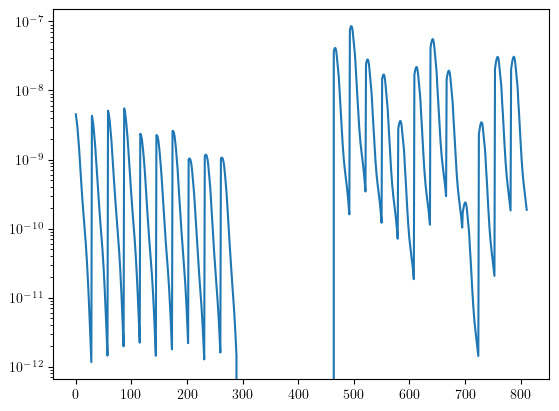

In [90]:
# F_all
# jnp.all(jnp.isfinite(P))
# dmu_cosmo_all.shape
pl.figure()
# pl.plot(np.abs(dmu_cosmo_all[:,0]))
pl.plot(np.abs(dmu_IA_all[:,1]))
# pl.plot(np.abs(dmu_sims_all[:,1]))
pl.yscale('log')




In [20]:
import dill
df = dill.load(open('/mnt/home/spandey/ceph/GODMAX/data/pge/Fisher_final_probes_ky_kk_gg_gy_gk_ge_ellmax_8000.pk','rb'))
F_all_8k = df['F_all']

df = dill.load(open('/mnt/home/spandey/ceph/GODMAX/data/pge/Fisher_final_probes_ky_kk_gg_gy_gk_ge_ellmax_1000.pk','rb'))
F_all_500 = df['F_all']


df = dill.load(open('/mnt/home/spandey/ceph/GODMAX/data/pge/Fisher_final_probes_kk_gg_gk_ge_ellmax_1000.pk','rb'))
F_kk_gg_gk_ge_500 = df['F_all']


df = dill.load(open('/mnt/home/spandey/ceph/GODMAX/data/pge/Fisher_final_probes_kk_gg_gk_ellmax_1000.pk','rb'))
F_kk_gg_gk_500 = df['F_all']



In [13]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as pl
def plot_contours(fisher, pos, inds=[1,0], nstd=1., ax=None,title=None, **kwargs):
  """
  Plot 2D parameter contours given a Hessian matrix of the likelihood
  """
  i,j = inds
  
  def eigsorted(cov):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    return vals[order], vecs[:, order]

  mat = fisher
  cov = np.linalg.inv(mat)
  sigma_marg = lambda i: np.sqrt(cov[i, i])

  if ax is None:
      ax = pl.gca()

  # Extracts the block we are interested in
  block_cov = cov[:,[i,j]][[i,j],:]
  vals, vecs = eigsorted(block_cov)
  theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

  # Width and height are "full" widths, not radius
  width, height = 2 * nstd * np.sqrt(vals)
  ellip = Ellipse(xy=pos[[i,j]], width=width,
                  height=height, angle=theta, **kwargs)

  ax.add_artist(ellip)
  sz = max(width, height)
  s1 = 1.5*nstd*sigma_marg(i)
  s2 = 1.5*nstd*sigma_marg(j)
  ax.set_xlim(pos[i] - s1, pos[i] + s1)
  ax.set_ylim(pos[j] - s2, pos[j] + s2)
  pl.draw()
  pl.xlabel(r'$\Omega_m$', fontsize=16)
  pl.ylabel(r'$\sigma_8$', fontsize=16)
  pl.xlim(0.29, 0.335)
  pl.ylim(0.815, 0.865)
  if title is not None:
    pl.title(title, fontsize=16)
  return ellip



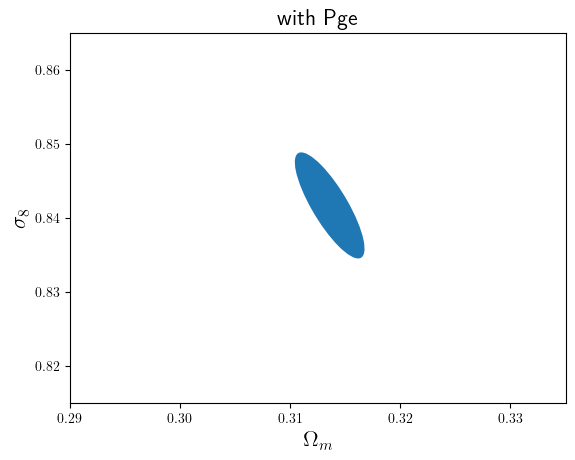

In [11]:
# plot_contours(F_all, cosmo_params_fid_all, inds=[0,4], title='with Pge')
plot_contours(F_all_500, cosmo_params_fid_all, inds=[0,4], title='with Pge')
    

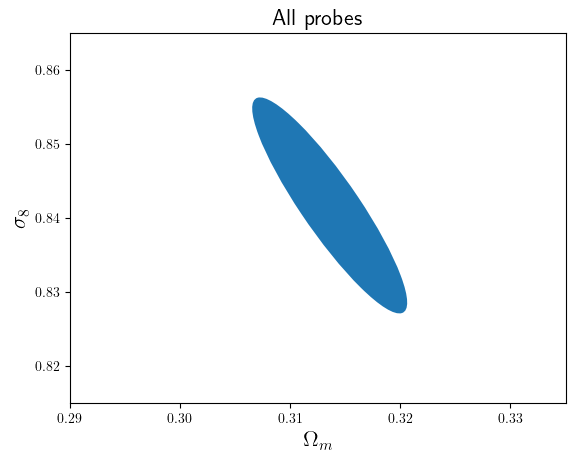

In [21]:
plot_contours(F_all_500, cosmo_params_fid_all, inds=[0,4], title='All probes')



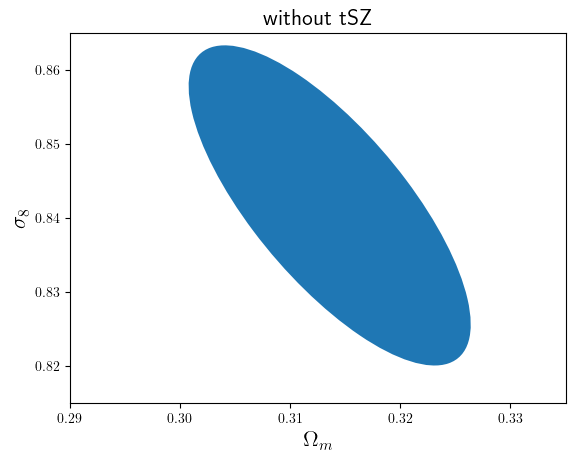

In [22]:
plot_contours(F_kk_gg_gk_ge_500, cosmo_params_fid_all, inds=[0,4], title='without tSZ')


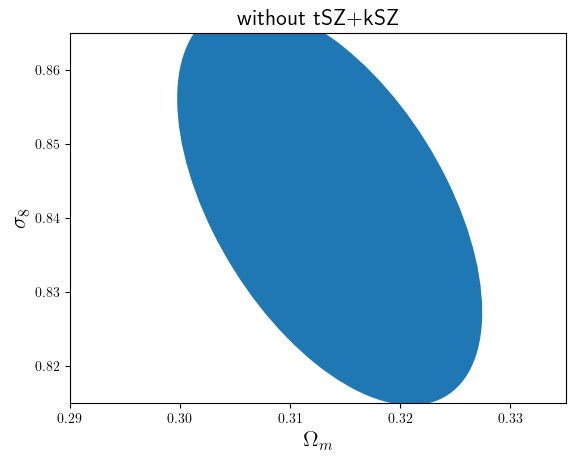

In [23]:
plot_contours(F_kk_gg_gk_500, cosmo_params_fid_all, inds=[0,4], title='without tSZ+kSZ')



ValueError: Axis limits cannot be NaN or Inf

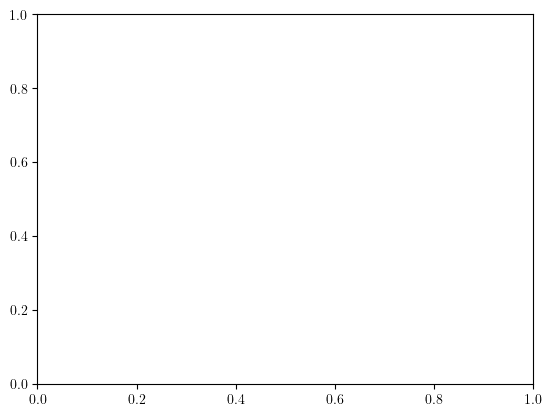

In [37]:
plot_contours(F_all, cosmo_params_fid_all, inds=[0,4])
